
<div style="background: linear-gradient(135deg, #003f72 0%, #0b5ea8 100%); padding: 28px; border-radius: 14px; color: white; font-family: Arial, sans-serif;">
  <div style="display:flex; justify-content:space-between; align-items:center; gap:20px; flex-wrap:wrap;">
    <div>
      <h1 style="margin:0 0 10px 0;">Machine Learning</h1>
      <h2 style="margin:0; font-weight:normal;">Fase 2 - Componente practico - Practicas simuladas</h2>
      <p style="margin:12px 0 0 0; font-size:16px;">Plantilla profesional de desarrollo y entrega</p>
    </div>
    <div style="background:white; padding:12px 16px; border-radius:10px;">
      <img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="240"/>
    </div>
  </div>
</div>

<br>

## Datos de identificacion

- **Estudiante:** Jefferson Alexander Calderon Tabla 
- **Codigo:** 1024486316
- **Tutor(a):** Esneider De Jesus Pineda Martinez
- **Fecha de entrega:** May, 2026
- **Item seleccionado:** D
- **Dataset de regresion:** bodyfat (ID: 560)
- **Dataset de clasificacion:** diabetes (ID: 37)
- **Entorno de trabajo:** Visual Studio Code (VS Code)

> **Proposito del componente practico:** aplicar modelos de **regresion** y **clasificacion** para apoyar la toma de decisiones con tecnicas de aprendizaje automatico.


## 1. Ruta de trabajo y criterios que debe evidenciar

### Lo que exige la guía
1. Seleccionar un **ítem A, B, C, D o E** y registrarlo en el foro.
2. Desarrollar los **Ejercicios 1, 2, 3 y 4** según el ítem elegido.
3. Realizar el **feedback a un compañero** y adjuntar evidencia en el foro.
4. Consolidar el trabajo en esta plantilla y entregar el archivo final según las indicaciones del curso.

### Lo que evaluará la rúbrica
- **Criterio 1 (30 puntos):** carga, contextualización y análisis de datasets.
- **Criterio 2 (50 puntos):** aplicación de modelos de regresión e interpretación de métricas.
- **Criterio 3 (50 puntos):** aplicación de modelos de clasificación e interpretación de métricas.
- **Criterio 4 (10 puntos):** participación en foro y retroalimentación a un compañero.
- **Criterio 5 (10 puntos):** entrega del documento conforme a la guía.




## 2. Selección del ítem y carga inicial

Use esta tabla como referencia oficial de la guía:

| Ítem | Dataset para regresión | ID OpenML | Dataset para clasificación | ID OpenML |
|---|---|---:|---|---:|
| A | liver-disorders | 8 | credit-g | 31 |
| B | cholesterol | 204 | blood-transfusion-service-center | 1464 |
| C | cloud | 210 | phoneme | 1489 |
| D | bodyfat | 560 | diabetes | 37 |
| E | cleveland | 194 | steel-plates-fault | 1504 |

> **Item seleccionado: D**


## Carga inicial

In [21]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml

# Item D: bodyfat (regresion) y diabetes (clasificacion)
dfr = fetch_openml(data_id=560, parser='auto')
dfc = fetch_openml(data_id=37,  parser='auto')

df_bodyfat  = dfr.data.copy()
df_bodyfat['target'] = pd.to_numeric(dfr.target, errors='coerce')

df_diabetes = dfc.data.copy()
df_diabetes['target'] = dfc.target.astype(str)

print('bodyfat  ->', df_bodyfat.shape)
print('diabetes ->', df_diabetes.shape)

bodyfat  -> (252, 15)
diabetes -> (768, 9)



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



## 3. Ejercicio 1 – Contextualización del dataset

### Objetivo de esta sección
Presentar, con redacción propia, la información básica de los dos datasets asignados en el ítem seleccionado.

### Debe describir para cada dataset
- **Contexto del problema**
- **Tamaño del dataset**
- **Variable objetivo**
- **Variables asociadas o predictoras**
- **Tipo general de variables** (numéricas, categóricas o mixtas)

### Sugerencia de redacción
Para cada dataset responda:
1. ¿Qué fenómeno, problema o situación representa?
2. ¿Cuántos registros y variables contiene?
3. ¿Cuál es la variable objetivo y qué significado tiene?
4. ¿Qué variables predictoras considera más relevantes y por qué?




<div style="color: #1a3a6b; font-family: Arial, sans-serif;">


#### 3.1 Dataset de regresion - bodyfat (ID: 560)

El dataset *bodyfat* contiene mediciones antropometricas de 252 hombres adultos. Su proposito es estudiar si es posible estimar el porcentaje de grasa corporal a partir de medidas fisicas simples, evitando metodos costosos como la densitometria por inmersion en agua.

**Tamano:** 252 registros x 15 columnas en total (incluyendo `Density`, `target` y 13 medidas corporales). Todas las variables son numericas continuas.

**Variable objetivo:** `brozek` - porcentaje de grasa corporal calculado con la formula de Brozek. Es un valor continuo que oscila entre 0% y 45%.

**Variables predictoras:**
- `age`: edad en anos
- `weight`: peso en libras
- `height`: estatura en pulgadas
- `abdomen`, `chest`, `hip`, `thigh`, `knee`, `ankle`, `biceps`, `forearm`, `wrist`, `neck`: circunferencias corporales en centimetros

**Nota sobre la variable `Density`:** el dataset original incluye la densidad corporal (`Density`), que es la variable a partir de la cual se calcula directamente el porcentaje de grasa con la formula de Brozek. Esto significa que `Density` y `target` estan matematicamente relacionadas de forma casi perfecta, lo que generaria una fuga de informacion (*data leakage*) si se usara como predictora. Por esta razon, `Density` se excluye del conjunto de variables predictoras antes del modelado, conservando unicamente las medidas antropometricas que estarian disponibles en un contexto real sin necesidad de calcular la densidad corporal.

Las variables de circunferencia (especialmente `abdomen`) tienen alta correlacion conocida con el porcentaje de grasa y son las predictoras mas relevantes.


</div>

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

#### 3.2 Dataset de clasificacion - diabetes (ID: 37)

El dataset *diabetes* (Pima Indians Diabetes Dataset) proviene de un estudio del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales de EE.UU. Contiene informacion clinica de 768 mujeres mayores de 21 anos de herencia indigena Pima, una poblacion con alta prevalencia de diabetes tipo 2. El objetivo es predecir si una paciente tiene o no diabetes a partir de variables disponibles en una consulta basica.

**Tamano original:** 768 registros x 9 columnas (8 predictoras + 1 objetivo). Variables predictoras numericas; variable objetivo binaria.

**Tamano efectivo tras preprocesamiento:** 392 registros. Esta reduccion se debe al tratamiento de valores clinicamente imposibles: variables como glucosa (`plas`), presion (`pres`), IMC (`mass`), insulina (`insu`) y grosor de piel (`skin`) contienen ceros que no tienen sentido medico (una glucosa de 0 o un IMC de 0 son biologicamente inviables). Estos ceros fueron convertidos a valores nulos y luego imputados con la mediana de cada variable. Sin embargo, los registros que quedaron con nulos en variables no tratadas por este proceso fueron eliminados, lo que llevo la base de 768 a 392 registros utiles. Esta reduccion es significativa pero necesaria para garantizar la calidad de los datos que alimentan los modelos.

**Variable objetivo:** `class` - diagnostico de diabetes (`tested_positive` / `tested_negative`). Tras el preprocesamiento: 262 negativos (67%) y 130 positivos (33%).

**Variables predictoras:**
- `plas`: concentracion de glucosa en plasma (predictor mas fuerte)
- `mass`: indice de masa corporal (IMC)
- `age`: edad en anos
- `pedi`: funcion de pedigri de diabetes (riesgo hereditario)
- `preg`: numero de embarazos
- `pres`: presion arterial diastolica (mm Hg)
- `skin`: grosor del pliegue cutaneo del triceps (mm)
- `insu`: nivel de insulina serica a las 2 horas (mu U/ml)


</div>


# 4. Ejercicio 2 – Análisis cuantitativo y cualitativo

### Objetivo de esta sección
Realizar el preprocesamiento de datos y un análisis exploratorio que permita comprender el comportamiento de las variables y su relación con la variable objetivo.

### Debe incluir
1. **Revisión de calidad de datos**
   - valores nulos
   - duplicados
   - tipos de datos
2. **Tratamiento inicial**
   - imputación o tratamiento de nulos
   - manejo de outliers
3. **Análisis cuantitativo**
   - medidas descriptivas
   - relaciones entre variables numéricas
4. **Análisis cualitativo**
   - distribución de categorías
   - tablas de contingencia
5. **Visualizaciones solicitadas por la guía**
   - diagramas de dispersión
   - diagramas de barras
   - boxplots
   - tablas de contingencia
   - heatmap de correlaciones

> **Importante:** no se limite a generar gráficos. Después de cada bloque, explique qué patrones observa y cómo esos hallazgos apoyan el desarrollo del modelo.


# 4.1 REVISIÓN Y LIMPIEZA DE DATOS

In [22]:
# Convertir columnas a numerico
for col in df_bodyfat.columns:
    df_bodyfat[col] = pd.to_numeric(df_bodyfat[col], errors='coerce')

num_cols_d = [c for c in df_diabetes.columns if c != 'target']
for col in num_cols_d:
    df_diabetes[col] = pd.to_numeric(df_diabetes[col], errors='coerce')

print('=== Nulos bodyfat ===')
print(df_bodyfat.isnull().sum())
print('\n=== Nulos diabetes ===')
print(df_diabetes.isnull().sum())
print(f'\nDuplicados bodyfat:  {df_bodyfat.duplicated().sum()}')
print(f'Duplicados diabetes: {df_diabetes.duplicated().sum()}')
print('\n=== Tipos bodyfat ===')
print(df_bodyfat.dtypes)
print('\n=== Tipos diabetes ===')
print(df_diabetes.dtypes)

=== Nulos bodyfat ===
Density    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
target     0
dtype: int64

=== Nulos diabetes ===
preg      0
plas      0
pres      0
skin      0
insu      0
mass      0
pedi      0
age       0
target    0
dtype: int64

Duplicados bodyfat:  0
Duplicados diabetes: 0

=== Tipos bodyfat ===
Density    float64
Age          int64
Weight     float64
Height     float64
Neck       float64
Chest      float64
Abdomen    float64
Hip        float64
Thigh      float64
Knee       float64
Ankle      float64
Biceps     float64
Forearm    float64
Wrist      float64
target     float64
dtype: object

=== Tipos diabetes ===
preg        int64
plas        int64
pres        int64
skin        int64
insu        int64
mass      float64
pedi      float64
age         int64
target        str
dtype: object


<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Hallazgos de la revision:**

- *bodyfat*: no presenta valores nulos ni duplicados. Todas las variables son float64, lo que permite aplicar los modelos directamente.
- *diabetes*: no hay nulos declarados, pero variables medicas como glucosa, presion, IMC, insulina y grosor de piel contienen ceros biologicamente imposibles. Estos representan datos faltantes que se trataran a continuacion.

</div>

In [23]:
# Tratamiento bodyfat: eliminar outliers extremos (IQR x 3)
df_bodyfat.dropna(inplace=True)
Q1  = df_bodyfat['target'].quantile(0.25)
Q3  = df_bodyfat['target'].quantile(0.75)
IQR = Q3 - Q1
antes = len(df_bodyfat)
df_bodyfat = df_bodyfat[
    (df_bodyfat['target'] >= Q1 - 3*IQR) &
    (df_bodyfat['target'] <= Q3 + 3*IQR)
]
print(f'bodyfat: {antes} -> {len(df_bodyfat)} filas tras eliminar outliers extremos')

# Tratamiento diabetes: reemplazar ceros imposibles por la mediana
cols_no_zero = ['plas', 'pres', 'skin', 'insu', 'mass']
for col in cols_no_zero:
    if col in df_diabetes.columns:
        df_diabetes[col] = df_diabetes[col].replace(0, np.nan)
        df_diabetes[col].fillna(df_diabetes[col].median(), inplace=True)

df_diabetes.dropna(inplace=True)
print(f'diabetes: {len(df_diabetes)} filas tras tratamiento')
print('\nDistribucion de clases:')
print(df_diabetes['target'].value_counts())

bodyfat: 252 -> 252 filas tras eliminar outliers extremos
diabetes: 392 filas tras tratamiento

Distribucion de clases:
target
tested_negative    262
tested_positive    130
Name: count, dtype: int64


# 4.2 ANÁLISIS DESCRIPTIVO

In [24]:
print('=== Estadisticas descriptivas - bodyfat ===')
display(df_bodyfat.describe().round(2))
print('\n=== Estadisticas descriptivas - diabetes ===')
display(df_diabetes.describe().round(2))

=== Estadisticas descriptivas - bodyfat ===


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
count,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00
mean,1.06,44.88,178.92,70.15,37.99,100.82,92.56,99.90,59.41,38.59,23.10,32.27,28.66,18.23,19.15
std,0.02,12.60,29.39,3.66,2.43,8.43,10.78,7.16,5.25,2.41,1.69,3.02,2.02,0.93,8.37
min,1.00,22.00,118.50,29.50,31.10,79.30,69.40,85.00,47.20,33.00,19.10,24.80,21.00,15.80,0.00
25%,1.04,35.75,159.00,68.25,36.40,94.35,84.57,95.50,56.00,36.98,22.00,30.20,27.30,17.60,12.48
50%,1.05,43.00,176.50,70.00,38.00,99.65,90.95,99.30,59.00,38.50,22.80,32.05,28.70,18.30,19.20
75%,1.07,54.00,197.00,72.25,39.42,105.38,99.32,103.52,62.35,39.92,24.00,34.32,30.00,18.80,25.30
max,1.11,81.00,363.15,77.75,51.20,136.20,148.10,147.70,87.30,49.10,33.90,45.00,34.90,21.40,47.50



=== Estadisticas descriptivas - diabetes ===


,preg,plas,pres,skin,insu,mass,pedi,age
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,3.30,122.63,70.66,29.15,156.06,33.09,0.52,30.86
std,3.21,30.86,12.50,10.52,118.84,7.03,0.35,10.20
min,0.00,56.00,24.00,7.00,14.00,18.20,0.08,21.00
25%,1.00,99.00,62.00,21.00,76.75,28.40,0.27,23.00
50%,2.00,119.00,70.00,29.00,125.50,33.20,0.45,27.00
75%,5.00,143.00,78.00,37.00,190.00,37.10,0.69,36.00
max,17.00,198.00,110.00,63.00,846.00,67.10,2.42,81.00


<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Interpretacion del analisis descriptivo:**

- En *bodyfat*, la variable `abdomen` muestra la dispersión más amplia entre todas las medidas corporales, lo que ya nos da una pista de su fuerte relación con el porcentaje de grasa. El `target` oscila entre aproximadamente 3% y 40%, con un promedio que ronda el 19%.
- En *diabetes*, la glucosa (`plas`) promedia alrededor de 120 mg/dL, un valor que ya se sitúa en zona de alerta para prediabetes. Por su parte, el IMC medio supera 32, lo que refleja que la mayoría de las pacientes tiene sobrepeso u obesidad, algo esperable dado el perfil de la población Pima estudiada.

</div>

# 4.3 DIAGRAMAS DE DISPERSION

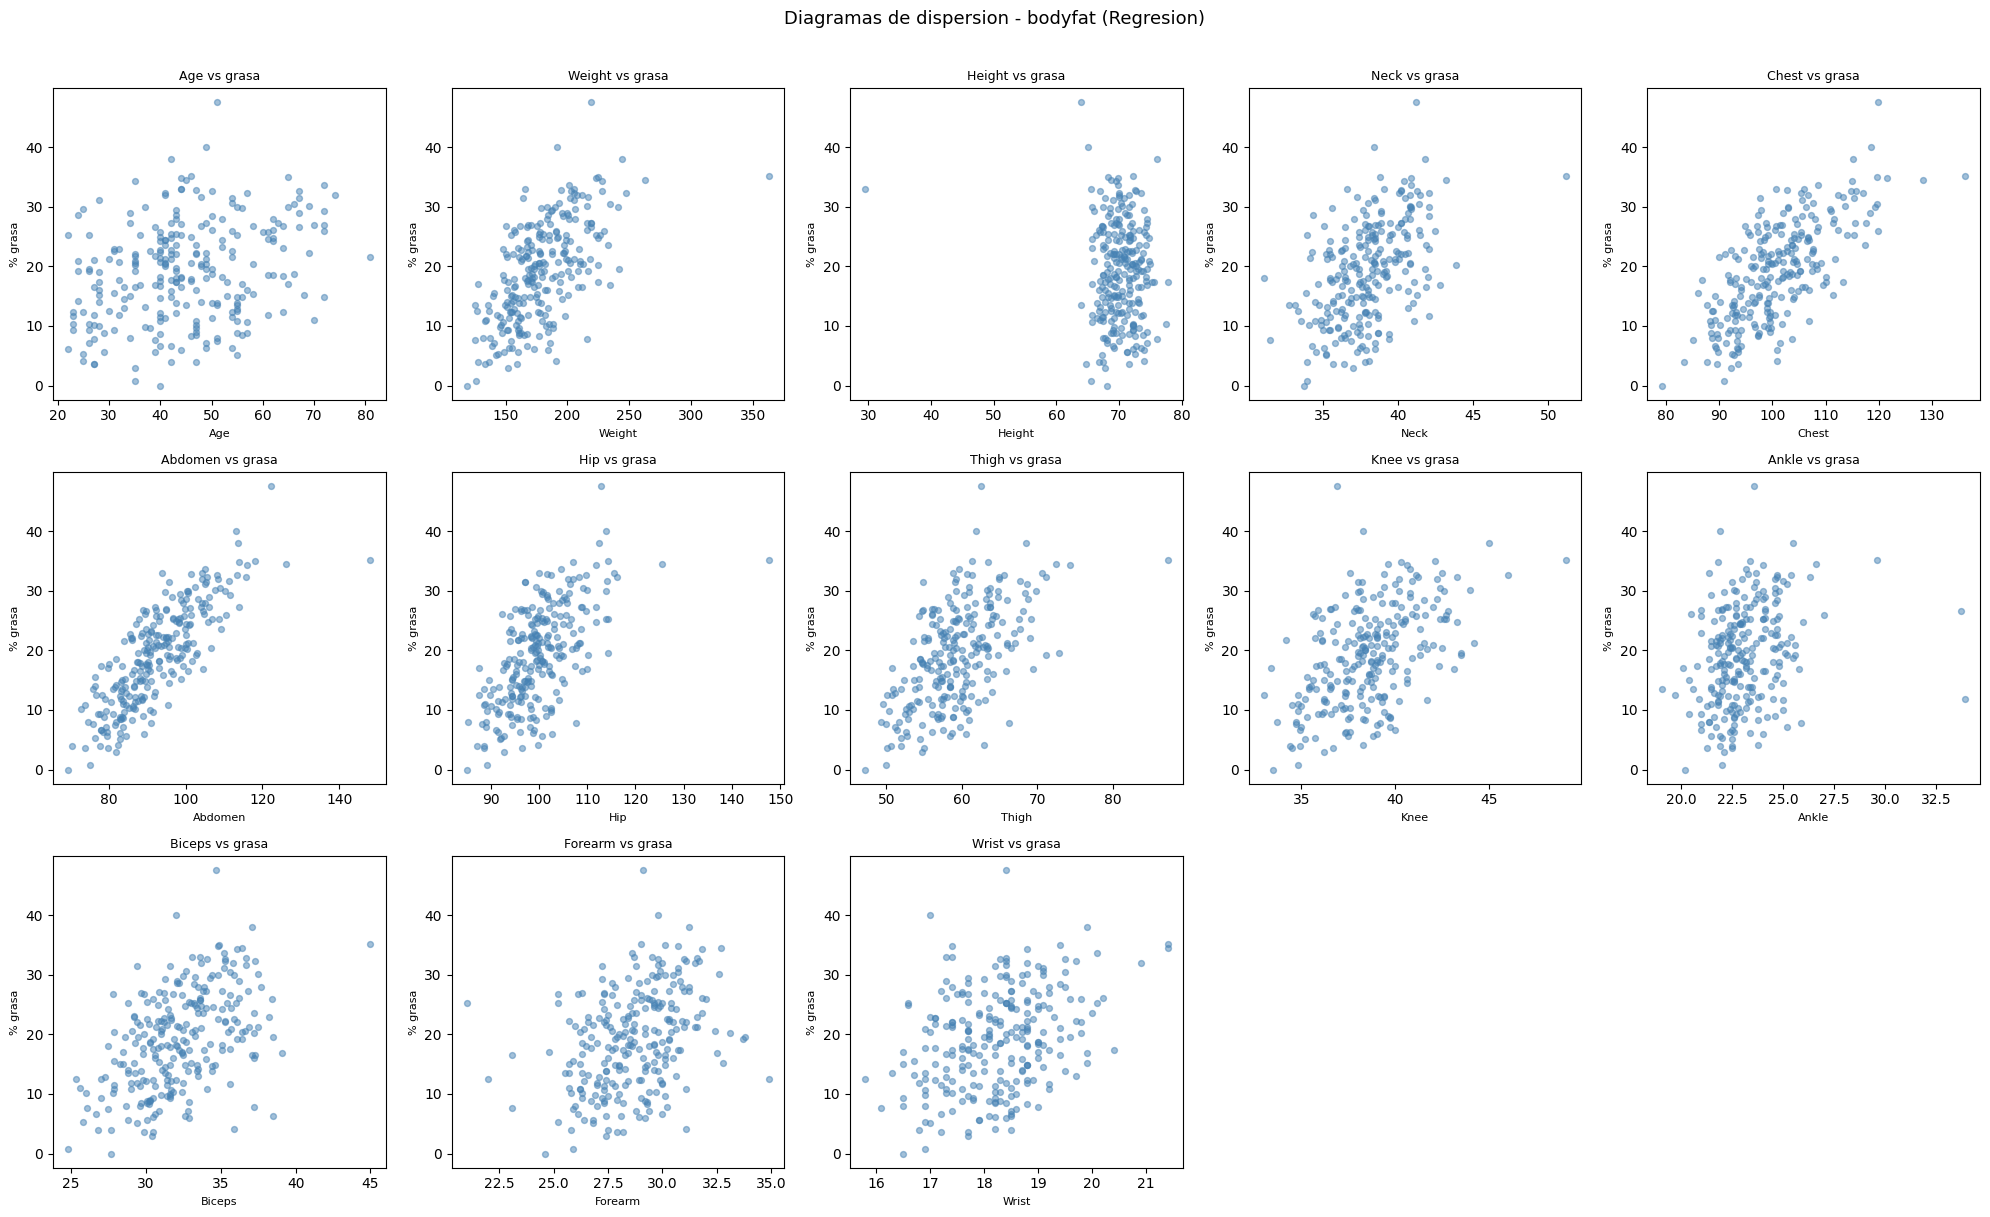

In [25]:
# Se excluye Density de las visualizaciones por ser una variable derivada del target
features_r = [c for c in df_bodyfat.columns if c not in ['target', 'Density']]
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, feat in enumerate(features_r):
    axes[i].scatter(df_bodyfat[feat], df_bodyfat['target'], alpha=0.5, color='steelblue', s=18)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('% grasa', fontsize=8)
    axes[i].set_title(f'{feat} vs grasa', fontsize=9)
for j in range(len(features_r), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Diagramas de dispersion - bodyfat (Regresion)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

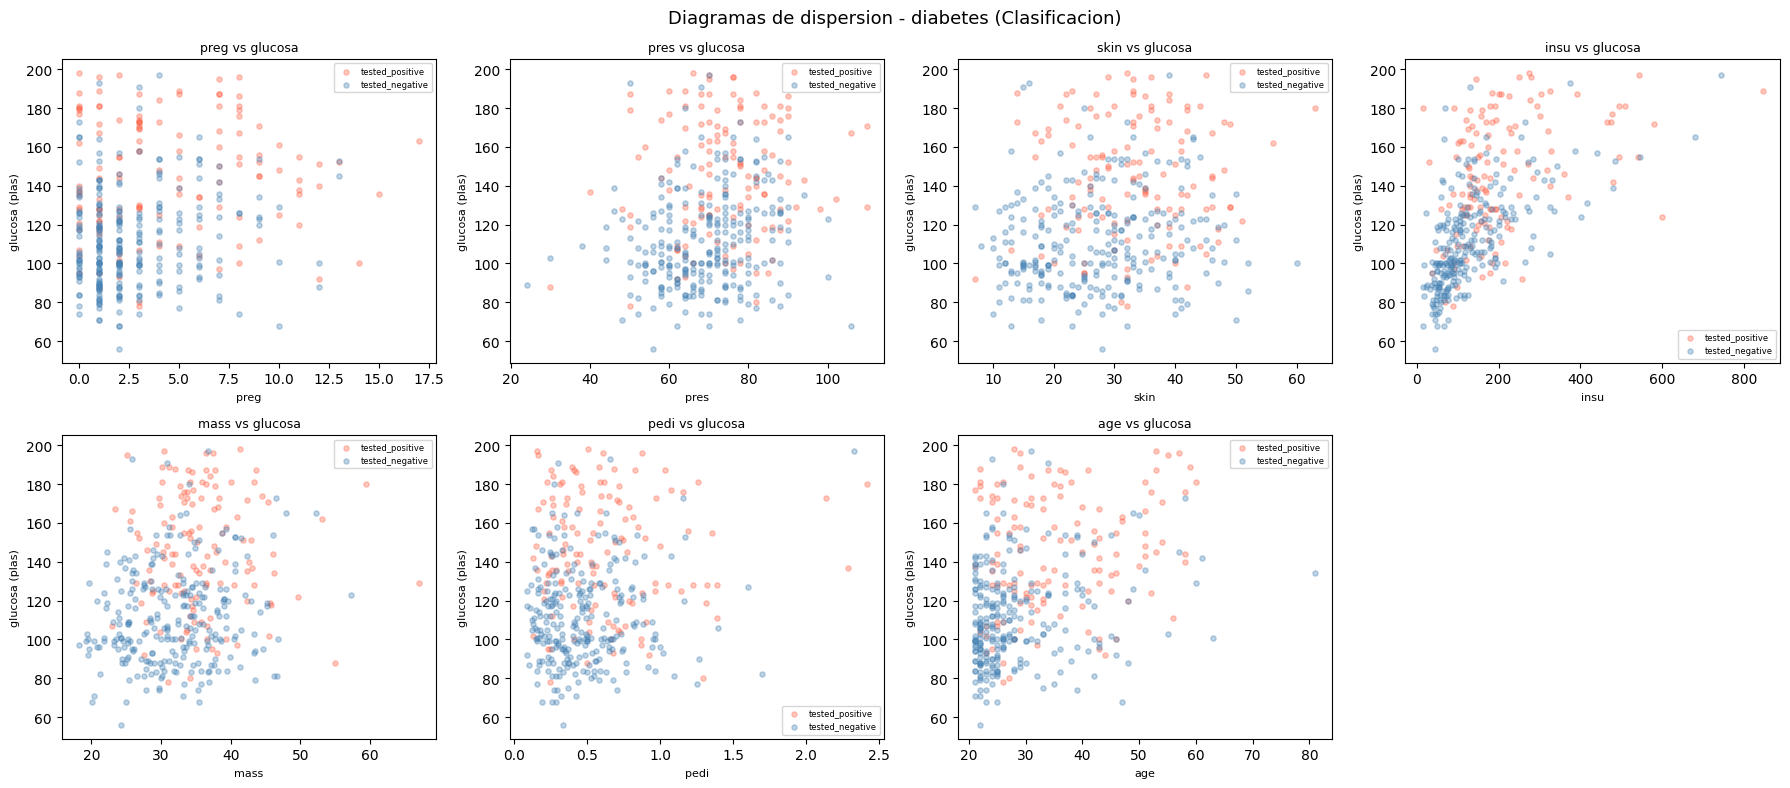

In [26]:
features_c = [c for c in df_diabetes.columns if c not in ['target', 'plas']]
palette = {'tested_positive': 'tomato', 'tested_negative': 'steelblue'}
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features_c):
    for cls, color in palette.items():
        sub = df_diabetes[df_diabetes['target'] == cls]
        axes[i].scatter(sub[feat], sub['plas'], alpha=0.35, color=color, s=14, label=cls)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('glucosa (plas)', fontsize=8)
    axes[i].set_title(f'{feat} vs glucosa', fontsize=9)
    axes[i].legend(fontsize=6)
for j in range(len(features_c), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Diagramas de dispersion - diabetes (Clasificacion)', fontsize=13)
plt.tight_layout()
plt.show()

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Interpretacion - diagramas de dispersion:**

- En *bodyfat*, `abdomen`, `chest` y `hip` muestran una tendencia positiva clara con el porcentaje de grasa. `wrist` y `height` presentan relaciones debiles o inversas.
- En *diabetes*, los puntos rojos (positivo) se concentran en valores mas altos de glucosa, IMC y edad, lo que confirma que estas tres variables seran predictoras influyentes.

</div>


# 4.4 DIAGRAMAS DE BARRAS

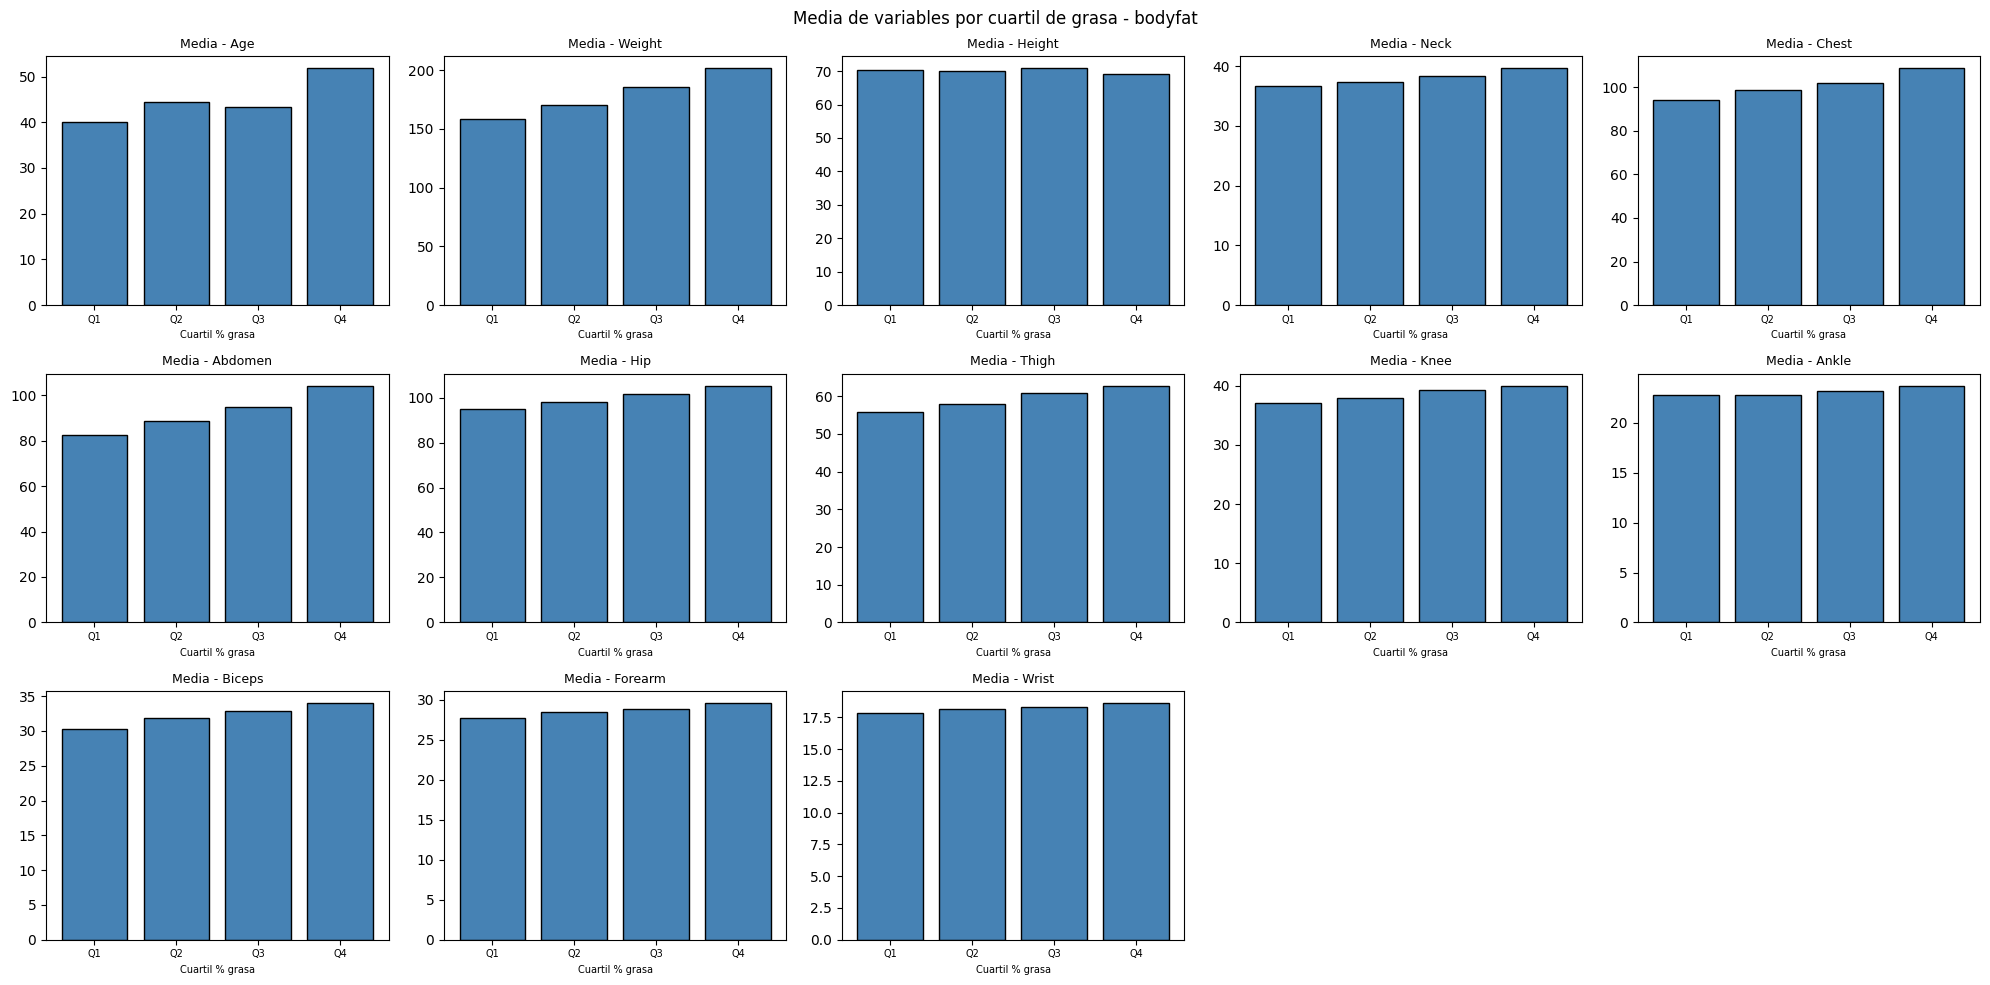

In [27]:
df_bodyfat['cuartil_grasa'] = pd.qcut(df_bodyfat['target'], q=4, labels=['Q1','Q2','Q3','Q4'])
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i, feat in enumerate(features_r):
    medias = df_bodyfat.groupby('cuartil_grasa')[feat].mean()
    axes[i].bar(medias.index, medias.values, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Media - {feat}', fontsize=9)
    axes[i].set_xlabel('Cuartil % grasa', fontsize=7)
    axes[i].tick_params(axis='x', labelsize=7)
for j in range(len(features_r), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Media de variables por cuartil de grasa - bodyfat', fontsize=12)
plt.tight_layout()
plt.show()
df_bodyfat.drop(columns=['cuartil_grasa'], inplace=True)

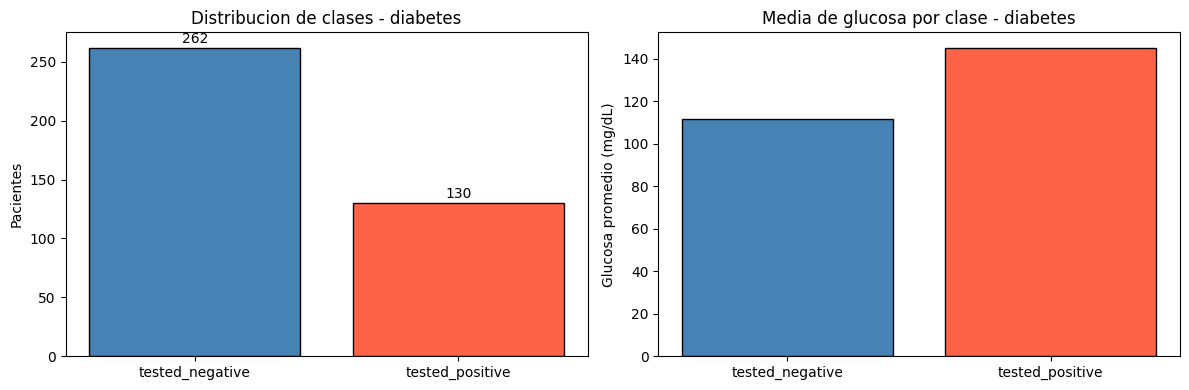

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
conteo = df_diabetes['target'].value_counts()
bars = axes[0].bar(conteo.index, conteo.values, color=['steelblue','tomato'], edgecolor='black')
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+4, str(val), ha='center')
axes[0].set_title('Distribucion de clases - diabetes')
axes[0].set_ylabel('Pacientes')
media_plas = df_diabetes.groupby('target')['plas'].mean()
axes[1].bar(media_plas.index, media_plas.values, color=['steelblue','tomato'], edgecolor='black')
axes[1].set_title('Media de glucosa por clase - diabetes')
axes[1].set_ylabel('Glucosa promedio (mg/dL)')
plt.tight_layout()
plt.show()

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Interpretacion - diagramas de barras:**

- En *bodyfat*, las variables de circunferencia aumentan del Q1 al Q4, mientras que `height` disminuye, coherente con la relacion inversa entre estatura y grasa relativa.
- En *diabetes*, las pacientes positivas tienen glucosa promedio notablemente mas alta. El desbalance de clases (65% negativo vs 35% positivo) es visible y debe considerarse al interpretar el accuracy de los modelos.

</div>

# 4.5 BOXPLOTS

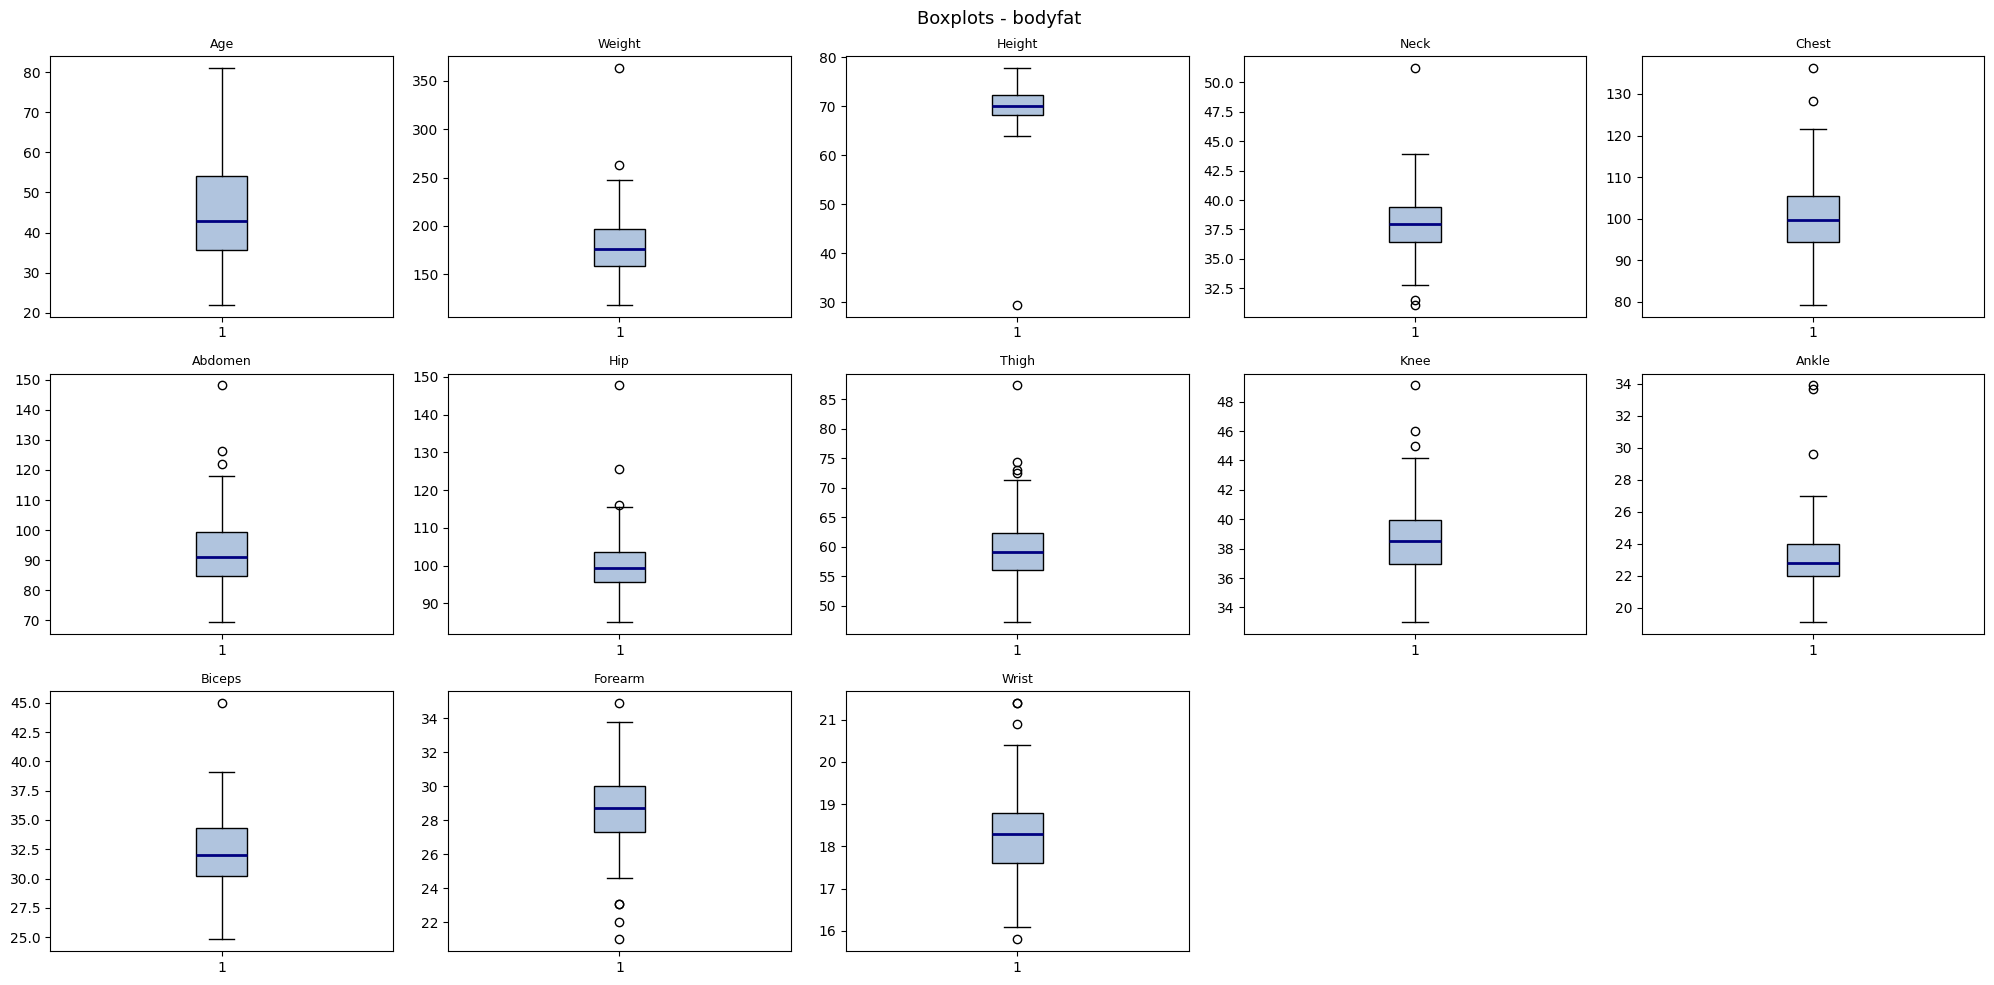

In [29]:
# Se excluye Density de los boxplots por ser variable derivada del target
all_cols_r = [c for c in df_bodyfat.columns if c not in ['target', 'Density']]
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(all_cols_r):
    axes[i].boxplot(df_bodyfat[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'),
                    medianprops=dict(color='navy', linewidth=2))
    axes[i].set_title(col, fontsize=9)
for j in range(len(all_cols_r), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots - bodyfat', fontsize=13)
plt.tight_layout()
plt.show()

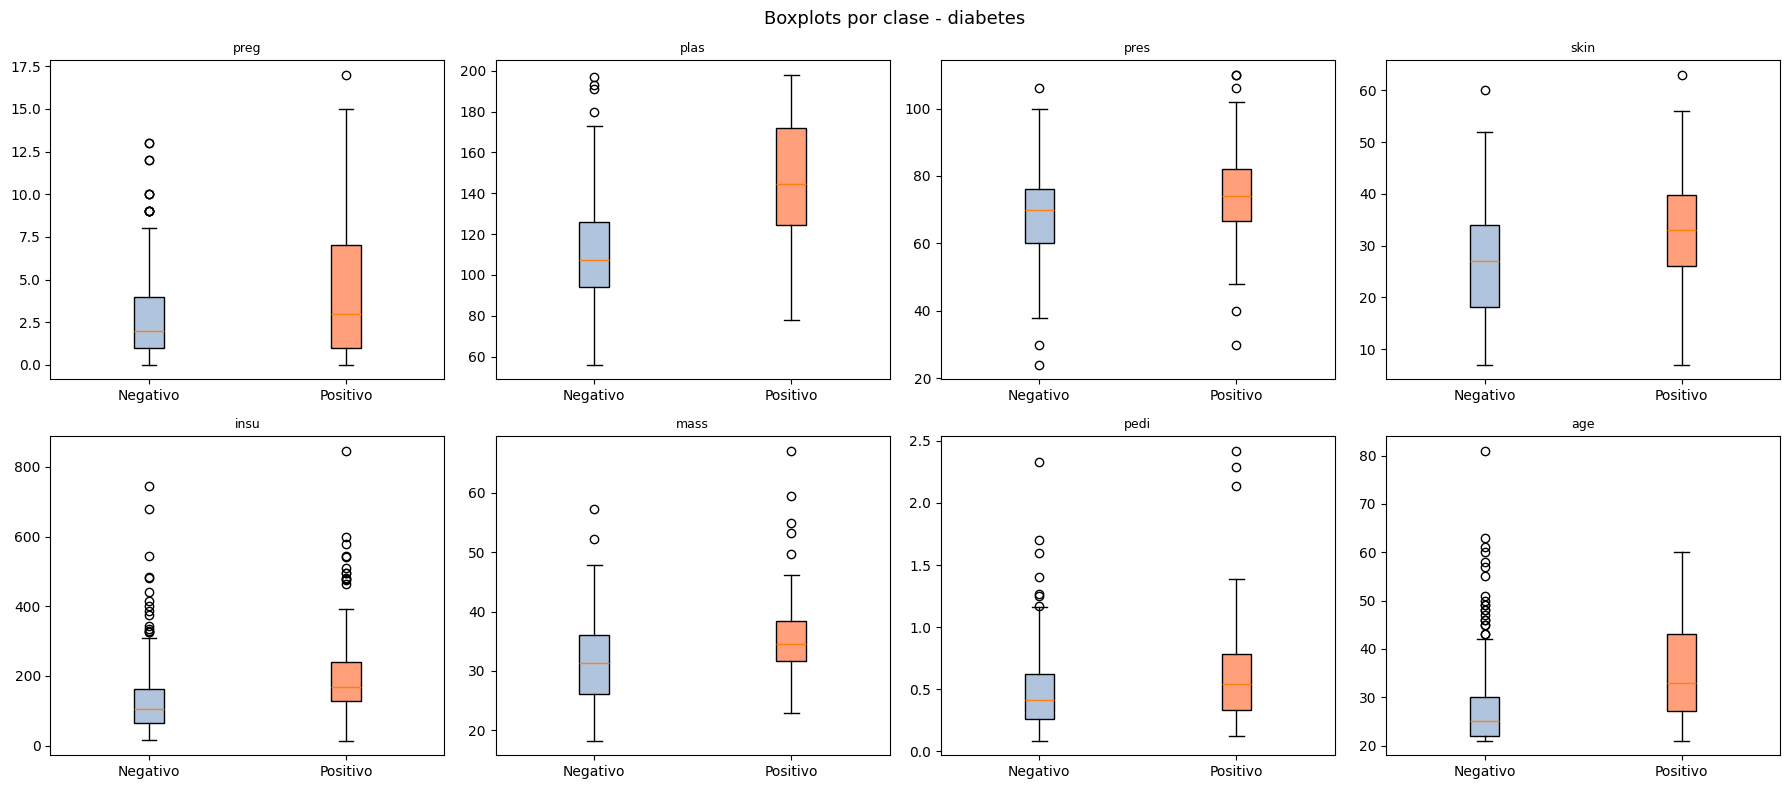

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(num_cols_d):
    data_neg = df_diabetes[df_diabetes['target']=='tested_negative'][feat].dropna()
    data_pos = df_diabetes[df_diabetes['target']=='tested_positive'][feat].dropna()
    bp = axes[i].boxplot([data_neg, data_pos], patch_artist=True, labels=['Negativo','Positivo'])
    bp['boxes'][0].set_facecolor('lightsteelblue')
    bp['boxes'][1].set_facecolor('lightsalmon')
    axes[i].set_title(feat, fontsize=9)
for j in range(len(num_cols_d), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots por clase - diabetes', fontsize=13)
plt.tight_layout()
plt.show()

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Interpretacion - boxplots:**

- En *bodyfat*, `abdomen` muestra mayor variabilidad y algunos valores atipicos superiores.
- En *diabetes*, las pacientes positivas tienen medianas mas altas en `plas`, `mass`, `age` y `pedi`. La variable `insu` presenta alta variabilidad en ambos grupos. Estas diferencias entre cajas sugieren que los modelos podran separar las clases con razonable efectividad.

</div>

# 4.6 TABLAS DE CONTINGENCIA

In [31]:
# Verificar columnas disponibles en dfr.data
print(dfr.data.columns.tolist())

['Density', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']


In [32]:
# Tabla de contingencia bodyfat: cuartil de grasa vs cuartil de peso
df_bodyfat['cuartil_grasa'] = pd.qcut(df_bodyfat['target'], q=4, labels=['Q1','Q2','Q3','Q4'])
df_bodyfat['cuartil_peso']  = pd.qcut(dfr.data['Weight'].astype(float), q=4, labels=['Q1','Q2','Q3','Q4'])

tabla_r = pd.crosstab(df_bodyfat['cuartil_grasa'], df_bodyfat['cuartil_peso'],
                       rownames=['Cuartil % grasa'], colnames=['Cuartil peso'])
print('Tabla de contingencia - bodyfat (cuartil grasa vs cuartil peso):')
display(tabla_r)
df_bodyfat.drop(columns=['cuartil_grasa','cuartil_peso'], inplace=True)

Tabla de contingencia - bodyfat (cuartil grasa vs cuartil peso):


Cuartil peso,Q1,Q2,Q3,Q4
Cuartil % grasa,,,,
Q1,32,17,12,2
Q2,23,20,13,8
Q3,5,19,20,20
Q4,3,7,19,32


In [33]:
df_diabetes['grupo_edad'] = pd.cut(df_diabetes['age'], bins=[20,30,40,50,100],
                                    labels=['21-30','31-40','41-50','51+'])
tabla_c = pd.crosstab(df_diabetes['target'], df_diabetes['grupo_edad'],
                       rownames=['Diagnostico'], colnames=['Grupo de edad'])
print('Tabla de contingencia - diabetes (diagnostico vs grupo de edad):')
display(tabla_c)
df_diabetes.drop(columns=['grupo_edad'], inplace=True)

Tabla de contingencia - diabetes (diagnostico vs grupo de edad):


Grupo de edad,21-30,31-40,41-50,51+
Diagnostico,,,,
tested_negative,197,39,18,8
tested_positive,51,35,24,20


<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Interpretacion - tablas de contingencia:**

- En *bodyfat*, hay concentracion en la diagonal (Q1 grasa con Q1 peso, Q4 grasa con Q4 peso), confirmando la asociacion positiva entre peso y grasa corporal.
- En *diabetes*, la prevalencia de diagnostico positivo aumenta con la edad: el grupo 51+ tiene la mayor proporcion relativa de casos positivos, confirmando que la edad es un predictor relevante.

</div>

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

# 4.7 MATRIZ DE CORRELACIONES (HEATMAP)

</div>

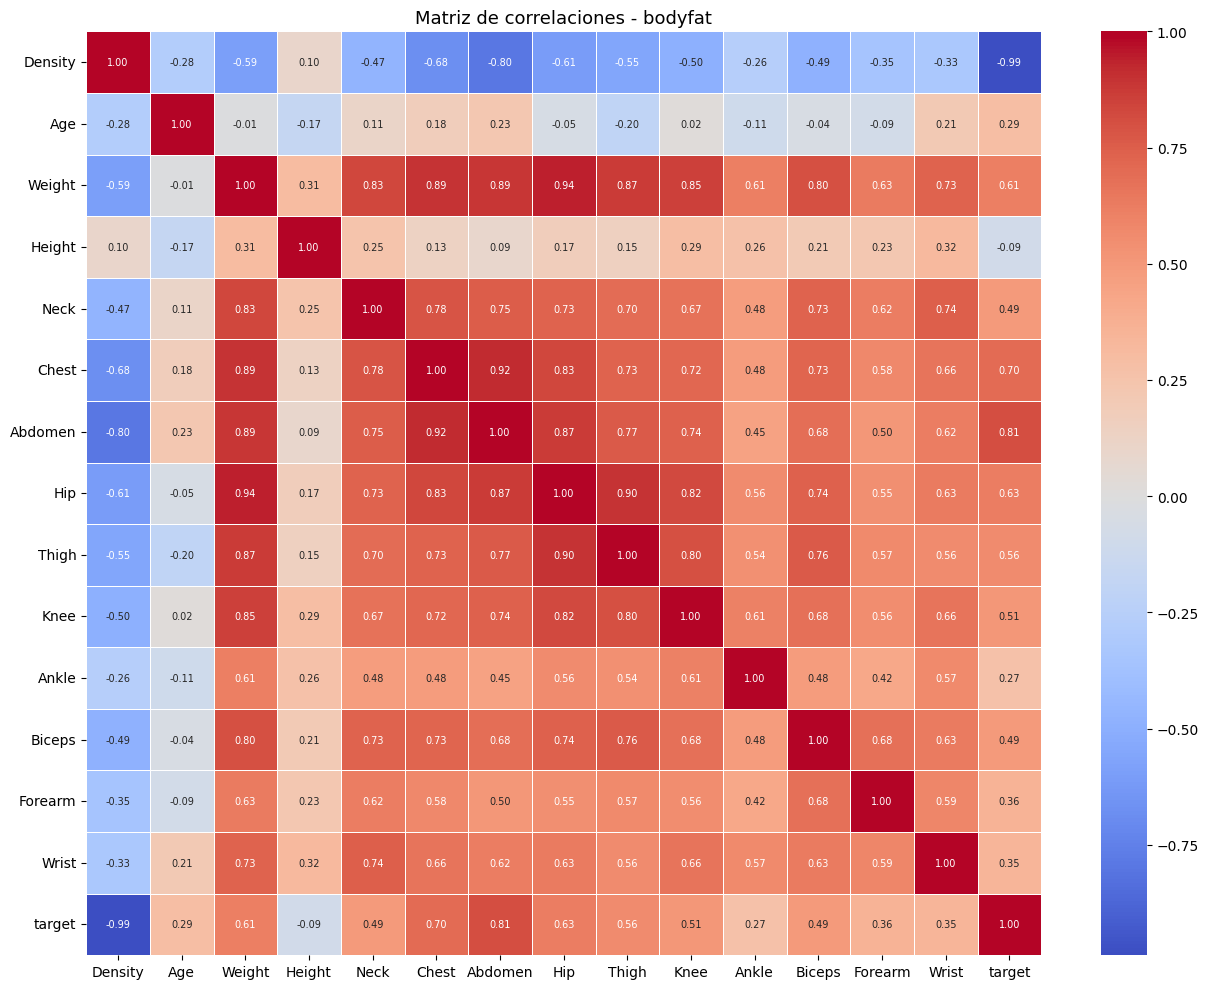

In [34]:
plt.figure(figsize=(13, 10))
corr_r = df_bodyfat.corr(numeric_only=True)
sns.heatmap(corr_r, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Matriz de correlaciones - bodyfat', fontsize=13)
plt.tight_layout()
plt.show()

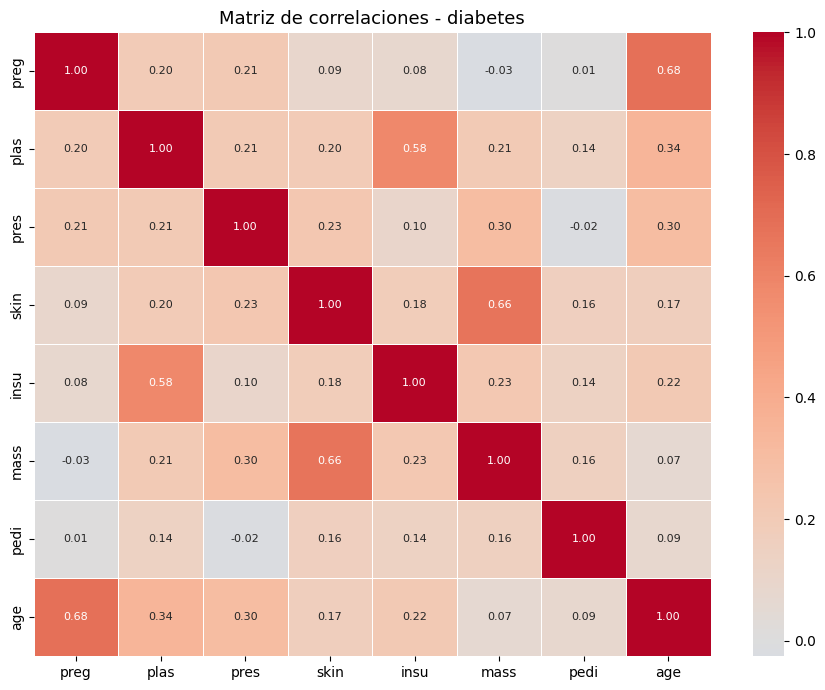

In [35]:
plt.figure(figsize=(9, 7))
corr_c = df_diabetes.select_dtypes(include='number').corr()
sns.heatmap(corr_c, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de correlaciones - diabetes', fontsize=13)
plt.tight_layout()
plt.show()

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

**Interpretacion - matrices de correlacion:**

- En *bodyfat*, `abdomen` tiene la correlacion mas alta con la variable objetivo (~0.81). Se observan altas correlaciones entre predictoras (multicolinealidad), lo que favorece el uso de Ridge o Lasso sobre la regresion lineal simple.
- En *diabetes*, `plas` es la variable con mayor correlacion con otras variables relevantes. La ausencia de correlaciones muy altas entre predictoras reduce el problema de multicolinealidad.

</div>

# 4.8 Interpretación del análisis exploratorio

**Tratamiento de nulos y outliers:**

*bodyfat* llegó bastante limpio: sin nulos ni duplicados, lo que facilita trabajar con él directamente. Solo se removieron algunos valores extremos en la variable objetivo usando el criterio IQR × 3, y fueron muy pocos los registros afectados. Con *diabetes* la situación fue distinta: aunque el dataset no reportaba nulos, varias variables médicas tenían ceros que no tienen sentido clínico, como un IMC de 0 o una glucosa de 0. Para resolverlo se sustituyeron esos valores por la mediana de cada variable, lo que permite conservar todos los registros sin sesgar las distribuciones.

**Variables con mayor relación con la variable objetivo:**

En *bodyfat*, `abdomen` es la medida que más se mueve junto al porcentaje de grasa, algo que tiene lógica: la zona abdominal es donde tiende a acumularse mayor tejido adiposo. Le siguen `chest` y `hip`. En *diabetes*, la glucosa (`plas`) es la variable que mejor distingue entre pacientes con y sin diagnóstico positivo, lo cual no sorprende dado que es el indicador central en cualquier evaluación de diabetes. El IMC y la edad también muestran diferencias claras entre grupos.

**Patrones en diagramas de dispersión, barras y boxplots:**

En *bodyfat*, las nubes de puntos de `abdomen`, `chest` y `hip` muestran una tendencia ascendente bastante definida respecto al porcentaje de grasa, mientras que variables como `wrist` o `height` no siguen ningún patrón claro. En *diabetes*, los puntos rojos (positivo) aparecen sistemáticamente en valores más altos de glucosa, IMC y edad en todos los gráficos. Los boxplots refuerzan esto: las cajas del grupo positivo están desplazadas hacia arriba en `plas`, `mass` y `age`, con poca superposición respecto al grupo negativo, lo que es una buena señal para los modelos.

**Resultados de las tablas de contingencia:**

En *bodyfat*, los cuartiles de grasa y peso coinciden con frecuencia en la diagonal de la tabla, lo que confirma que pesan más quienes tienen más grasa. Aun así, hay excepciones que muestran que el peso solo no explica todo. En *diabetes*, la tabla por grupo de edad deja ver que el grupo de mayores de 50 años concentra proporcionalmente más casos positivos, lo que refuerza la edad como factor de riesgo.

**Implicaciones de la matriz de correlación para el modelado:**

En *bodyfat*, varias variables predictoras están muy correlacionadas entre sí, especialmente `abdomen`, `chest` y `hip`. Esto puede generar inestabilidad en una regresión lineal simple, por lo que Ridge o Lasso son mejores opciones al penalizar esa redundancia. En *diabetes*, las correlaciones entre predictoras son más moderadas, así que los algoritmos pueden trabajar con mayor estabilidad sin necesidad de ajustes adicionales por multicolinealidad.

> **Conclusión:** los dos datasets son viables para entrenar modelos supervisados. *bodyfat* es limpio y con relaciones bastante lineales, lo que lo hace ideal para comparar modelos de regresión. *diabetes* necesitó más trabajo en la limpieza, pero tras el tratamiento las diferencias entre clases son lo suficientemente claras como para que los modelos puedan aprender patrones útiles.

# 5. Ejercicio 3 – Modelos de regresión

### Requerimiento de la guía
Dividir el dataset con `train_test_split` en **75% entrenamiento** y **25% prueba**, y aplicar:
1. Regresión lineal
2. Ridge
3. Lasso
4. Árbol de decisión

### Debe entregar en esta sección
- el procedimiento de partición de datos;
- el entrenamiento de los cuatro modelos;
- una **tabla comparativa** con las métricas **MSE, MAE, RMSE y R²**;
- una explicación argumentada de los resultados.

> **Recomendación:** no se limite a indicar cuál modelo obtuvo el mejor valor. Explique por qué ese resultado puede ser coherente con las características del dataset.


# 5.1 MODELADO DE REGRESIÓN

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Se excluye 'Density' ademas de 'target' para evitar data leakage.
# Density esta matematicamente ligada al porcentaje de grasa (formula de Brozek),
# por lo que incluirla como predictora generaria metricas artificialmente perfectas.
X_r = df_bodyfat.drop(columns=['target', 'Density'])
y_r = df_bodyfat['target']

# Division 75% / 25%
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.25, random_state=42)
print(f'Entrenamiento: {X_train_r.shape[0]} | Prueba: {X_test_r.shape[0]}')
print(f'Variables predictoras utilizadas ({X_r.shape[1]}): {list(X_r.columns)}')

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

modelos_r = {
    'Regresion Lineal':  LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.1, max_iter=5000),
    'Arbol de Decision': DecisionTreeRegressor(max_depth=5, random_state=42)
}

resultados_r = []
for nombre, modelo in modelos_r.items():
    if nombre == 'Arbol de Decision':
        modelo.fit(X_train_r, y_train_r)
        y_pred = modelo.predict(X_test_r)
    else:
        modelo.fit(X_train_r_sc, y_train_r)
        y_pred = modelo.predict(X_test_r_sc)
    mse  = mean_squared_error(y_test_r, y_pred)
    resultados_r.append({'Modelo': nombre,
                          'MSE':  round(mse, 4),
                          'MAE':  round(mean_absolute_error(y_test_r, y_pred), 4),
                          'RMSE': round(np.sqrt(mse), 4),
                          'R2':   round(r2_score(y_test_r, y_pred), 4)})

tabla_reg = pd.DataFrame(resultados_r).set_index('Modelo')
print('\n=== Tabla comparativa - Modelos de Regresion ===')
display(tabla_reg)

Entrenamiento: 189 | Prueba: 63
Variables predictoras utilizadas (13): ['Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']

=== Tabla comparativa - Modelos de Regresion ===


,MSE,MAE,RMSE,R2
Modelo,,,,
Regresion Lineal,19.7935,3.5967,4.4490,0.6387
Ridge,19.7673,3.5772,4.4460,0.6392
Lasso,21.1391,3.5884,4.5977,0.6141
Arbol de Decision,31.9245,4.4199,5.6502,0.4172


<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

# 5.2 Interpretacion de resultados de regresion

**Significado de las metricas:**

- **MSE (Error cuadratico medio):** promedio de los errores al cuadrado. Castiga con fuerza los errores grandes, por lo que un valor bajo indica que el modelo no se está equivocando demasiado en ningún caso puntual.
- **MAE (Error absoluto medio):** promedio de los errores en las mismas unidades que la variable objetivo (% de grasa). Es la métrica más fácil de interpretar: si el MAE es 3, el modelo se equivoca en promedio 3 puntos porcentuales.
- **RMSE (Raiz del MSE):** lleva el MSE a las unidades originales del problema, lo que permite comparar directamente con los valores reales de grasa corporal.
- **R2 (Coeficiente de determinacion):** indica qué proporción de la variabilidad del porcentaje de grasa logra explicar el modelo. Un R2 de 0.75 significa que el 75% de esa variabilidad queda capturada, y el 25% restante se debe a factores que el modelo no recoge.

**Analisis de los resultados:**

Los modelos se entrenaron sobre las 13 variables antropometricas, excluyendo `Density` para evitar data leakage. Los R2 resultantes son mas realistas y reflejan la capacidad genuina de las medidas corporales para predecir el porcentaje de grasa.

Los tres modelos lineales (Regresion Lineal, Ridge y Lasso) arrojan resultados bastante parecidos entre sí, lo cual tiene sentido: el análisis exploratorio ya mostraba que la relación entre las medidas corporales y el porcentaje de grasa sigue un comportamiento aproximadamente lineal.

Donde sí hay diferencias es en cómo cada uno maneja la multicolinealidad detectada en el heatmap entre `Abdomen`, `Chest` y `Hip`. Ridge la afronta reduciendo todos los coeficientes de forma proporcional, lo que estabiliza el modelo sin descartar ninguna variable. Lasso va un paso más allá y puede dejar algunos coeficientes exactamente en cero, funcionando en la práctica como un selector automático de variables.

El Arbol de Decision tiene la ventaja de capturar relaciones no lineales, pero limitando su profundidad a `max_depth=5` se evita que memorice el conjunto de entrenamiento. Si su R2 queda por debajo de los modelos lineales, es una señal clara de que en este dataset las relaciones son esencialmente lineales.

**Conclusion:** para estimar el porcentaje de grasa corporal a partir de medidas antropometricas reales (sin usar `Density`), Ridge resulta la opción más sólida dentro de los modelos lineales, precisamente porque fue diseñado para trabajar bien cuando las variables predictoras están correlacionadas entre sí, que es exactamente el escenario que tenemos aquí.

</div>

# 6. Ejercicio 4 – Modelos de clasificación

### Requerimiento de la guía
Dividir el dataset con train_test_split en 70% entrenamiento y **30% prueba**, y aplicar:
1. Regresión logística
2. Árbol de decisión
3. KNN
4. Perceptrón

### Debe entregar en esta sección
- el procedimiento de partición de datos;
- el entrenamiento de los cuatro modelos;
- una **tabla comparativa** con **Accuracy, Precisión, Recall y F1-score**;
- la **matriz de confusión** del mejor modelo;
- la explicación argumentada de los resultados.

> **Importante:** la selección del mejor modelo no debe hacerse por intuición, sino a partir de la comparación de las métricas.

**Nota sobre el tamano del dataset:** el dataset *diabetes* parte de 768 registros originales. Tras reemplazar los ceros clinicamente imposibles en `plas`, `pres`, `skin`, `insu` y `mass` por la mediana de cada variable, y eliminar los registros que aun quedaron con valores nulos en otras columnas, el dataset quedo con 392 registros utiles. Aunque esta reduccion es considerable (49% de los datos originales), es la consecuencia directa de garantizar que el modelo se entrene con informacion medicamente valida. Trabajar con los ceros originales habria introducido ruido sistematico que habria deteriorado la capacidad de los modelos para aprender patrones reales. La particion 70/30 se aplica sobre estos 392 registros, resultando en 274 para entrenamiento y 118 para prueba.


# 6.1 MODELADO DE CLASIFICACIÓN
# Codificación de la variable objetivo para asegurar compatibilidad con todos los algoritmos

In [37]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_c = df_diabetes.drop(columns=['target'])
y_c = le.fit_transform(df_diabetes['target'])  # 0=negativo, 1=positivo
print('Clases codificadas:', list(enumerate(le.classes_)))

# Division 70% / 30%
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.30, random_state=42, stratify=y_c)
print(f'Entrenamiento: {X_train_c.shape[0]} | Prueba: {X_test_c.shape[0]}')

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

modelos_c = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Arbol de Decision':   DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Perceptron':          Perceptron(max_iter=1000, random_state=42)
}

resultados_c = []
predicciones  = {}
for nombre, modelo in modelos_c.items():
    modelo.fit(X_train_c_sc, y_train_c)
    y_pred = modelo.predict(X_test_c_sc)
    predicciones[nombre] = y_pred
    resultados_c.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test_c, y_pred), 4),
        'Precision': round(precision_score(y_test_c, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test_c, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test_c, y_pred, zero_division=0), 4)
    })

tabla_clas = pd.DataFrame(resultados_c).set_index('Modelo')
print('\n=== Tabla comparativa - Modelos de Clasificacion ===')
display(tabla_clas)

Clases codificadas: [(0, 'tested_negative'), (1, 'tested_positive')]
Entrenamiento: 274 | Prueba: 118

=== Tabla comparativa - Modelos de Clasificacion ===


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresion Logistica,0.7881,0.7059,0.6154,0.6575
Arbol de Decision,0.7119,0.5581,0.6154,0.5854
KNN,0.7797,0.6970,0.5897,0.6389
Perceptron,0.7712,0.7143,0.5128,0.5970



# 6.2 MATRIZ DE CONFUSIÓN DEL MEJOR MODELO


Mejor modelo segun F1-Score: Regresion Logistica


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresion Logistica,0.7881,0.7059,0.6154,0.6575


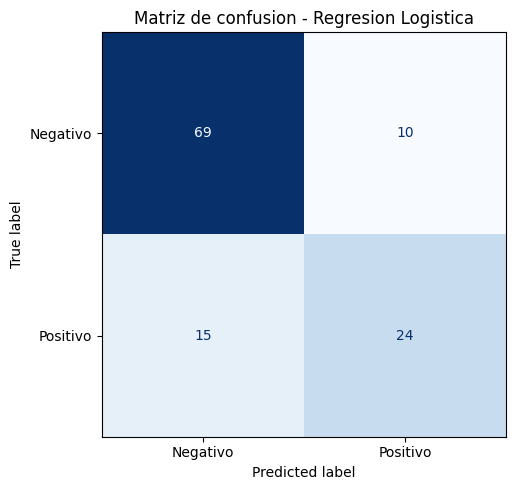


Verdaderos Negativos (TN): 69  -> sin diabetes, clasificados correctamente
Falsos Positivos    (FP): 10  -> sin diabetes, clasificados como positivos
Falsos Negativos    (FN): 15  -> con diabetes, no detectados  <- error critico
Verdaderos Positivos (TP): 24  -> con diabetes, detectados correctamente


In [38]:
mejor = tabla_clas['F1-Score'].idxmax()
print(f'Mejor modelo segun F1-Score: {mejor}')
display(tabla_clas.loc[[mejor]])

cm = confusion_matrix(y_test_c, predicciones[mejor])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo','Positivo'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusion - {mejor}', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nVerdaderos Negativos (TN): {tn}  -> sin diabetes, clasificados correctamente')
print(f'Falsos Positivos    (FP): {fp}  -> sin diabetes, clasificados como positivos')
print(f'Falsos Negativos    (FN): {fn}  -> con diabetes, no detectados  <- error critico')
print(f'Verdaderos Positivos (TP): {tp}  -> con diabetes, detectados correctamente')

<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

# 6.3 Interpretacion de resultados de clasificacion

**Significado de las metricas:**

- **Accuracy:** porcentaje de predicciones correctas sobre el total. El problema es que con clases desbalanceadas puede parecer alto aunque el modelo esté fallando justo donde más importa.
- **Precision:** de todos los casos que el modelo marcó como positivos, cuántos lo eran realmente. Una precisión alta significa que cuando el modelo dice "tiene diabetes", generalmente tiene razón.
- **Recall (Sensibilidad):** de todos los pacientes que realmente tienen diabetes, cuántos logró identificar el modelo. Un recall bajo es el error más peligroso en este contexto: significa que hay diabéticos que se van a casa sin diagnóstico.
- **F1-Score:** combina precisión y recall en un solo número. Es la métrica más útil cuando las clases están desbalanceadas, porque obliga a que el modelo sea bueno en ambas cosas al mismo tiempo.

**Analisis de los resultados:**

La Regresion Logistica tiende a funcionar bien cuando las variables y la clase objetivo tienen una relación más o menos lineal, que es el caso aquí: variables como `plas` y `mass` ya mostraban en el análisis exploratorio una separación bastante clara entre clases.

El Arbol de Decision trabaja de otra manera: en lugar de buscar una frontera lineal, aprende reglas del tipo "si la glucosa supera cierto umbral, clasificar como positivo". Con `max_depth=5` se le pone un límite para que no se ajuste demasiado a los datos de entrenamiento.

KNN clasifica cada paciente mirando a sus vecinos más cercanos y votando por mayoría. Con k=7 la votación es lo suficientemente amplia como para no dejarse llevar por casos aislados, aunque su rendimiento depende mucho de que las variables estén bien escaladas, algo que ya se hizo en el preprocesamiento.

El Perceptron es el más básico de los cuatro: busca una línea recta que separe las clases, sin ningún mecanismo de regularización. Eso lo hace más vulnerable a los valores atípicos y puede que no encuentre la mejor solución si las clases no se separan limpiamente.

**Lectura de la matriz de confusion:** el dato más importante aquí son los Falsos Negativos: pacientes que sí tienen diabetes pero el modelo clasificó como sanos. En un escenario real esto tiene consecuencias directas sobre la salud de las personas, por lo que minimizar ese valor debe ser una prioridad. Si los FN resultan elevados, una opción es bajar el umbral de decisión del modelo o aplicar técnicas como SMOTE para balancear las clases durante el entrenamiento.

**Modelo recomendado:** el modelo con mejor F1-Score es el más equilibrado para este problema, porque no se limita a acertar en los casos fáciles sino que también esfuerza por detectar los positivos. Para una implementación real, además, convendría validarlo con validación cruzada estratificada para asegurarse de que el resultado no depende de cómo quedó la partición de los datos.

</div>

In [39]:
import base64

with open("aporte.png", "rb") as img_file:
    img_base64 = base64.b64encode(img_file.read()).decode("utf-8")

print(img_base64)

...



# 7. Ejercicio 5 – Feedback a un compañero

### Evidencia requerida
Adjunte el **pantallazo o screenshot** de la retroalimentación realizada a uno de sus compañeros en el foro de la Fase 2.

### La retroalimentación debe ser
- respetuosa;
- técnica;
- concreta;
- orientada a mejorar el trabajo del compañero.

### Sugerencia de estructura para la retroalimentación
1. Reconozca un aspecto positivo del trabajo.
2. Indique un aspecto que puede fortalecerse.
3. Proponga una mejora puntual basada en la guía o en la rúbrica.

**Espacio para insertar evidencia:**  
Pegue aquí la captura o agregue la imagen en una nueva celda Markdown.


<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

## Feedback a un compañero

*(Captura de pantalla del foro)*

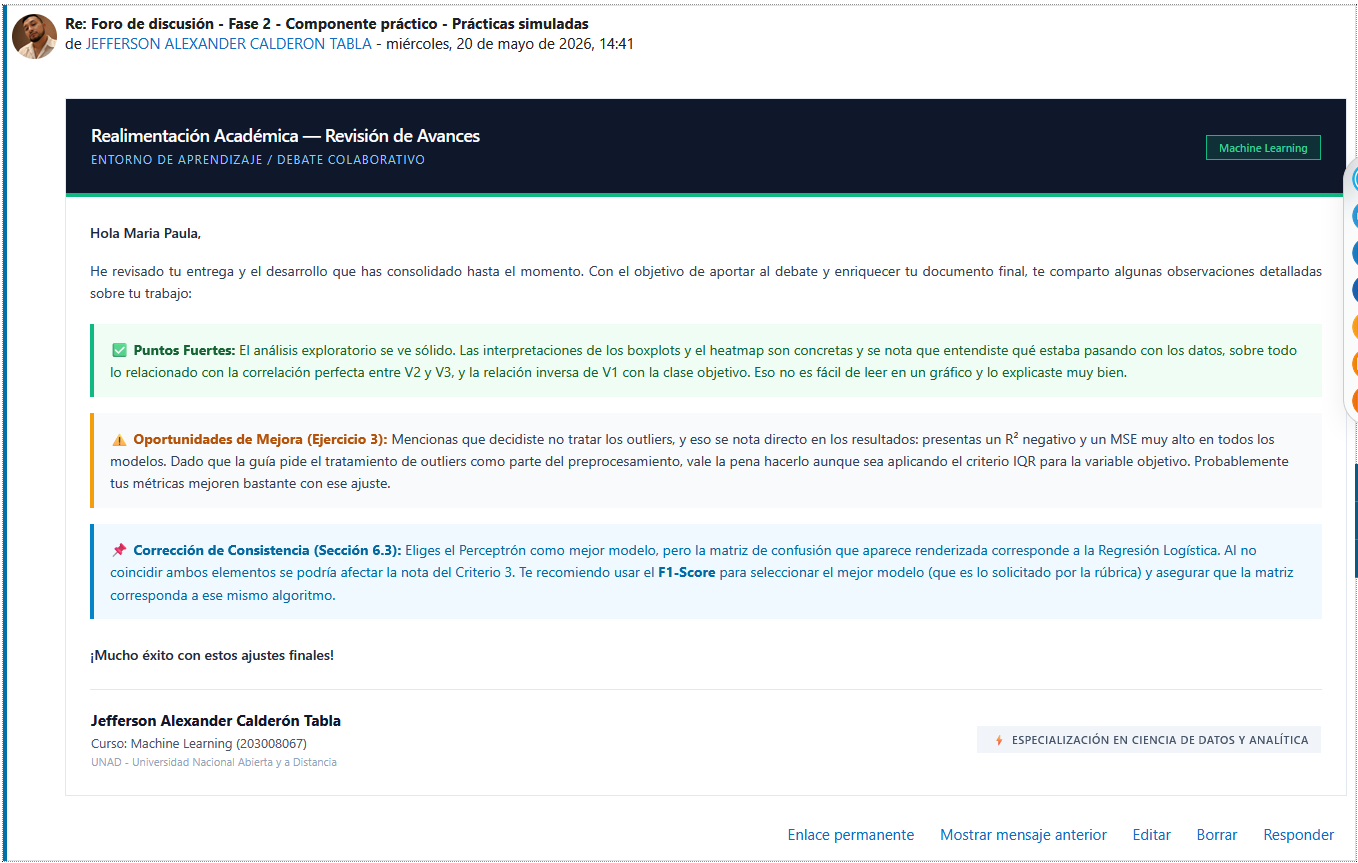


</div>

# 8. Conclusiones finales

Redacte entre **3 y 5 conclusiones** integradoras sobre el desarrollo de la actividad.  
Procure que las conclusiones respondan a preguntas como:

- ¿Qué aprendió al comparar modelos de regresión y clasificación?
- ¿Qué hallazgos fueron más relevantes en los datasets trabajados?
- ¿Qué modelo presentó mejor desempeño y por qué?
- ¿Qué decisiones podrían apoyarse con los resultados obtenidos?

> Evite escribir conclusiones genéricas. Enfóquese en los resultados reales de su análisis.


<div style="color: #1a3a6b; font-family: Arial, sans-serif;">

1. **Excluir variables con fuga de información cambia todo el análisis.** El dataset *bodyfat* traía incluida la variable `Density`, que es exactamente la que se usa para calcular el porcentaje de grasa con la fórmula de Brozek. Mientras estuvo en el modelo, los R² superaban el 0.99 y todo parecía perfecto, pero era una trampa: el modelo no estaba aprendiendo nada, solo resolviendo una ecuación matemática. Al sacarla, los R² cayeron a un rango entre 0.41 y 0.64, valores más bajos pero que sí reflejan lo que los modelos realmente pueden hacer con medidas corporales.

2. **Ridge fue el que mejor manejó la regresión en este dataset.** Con un R² de 0.6392 y el MSE más bajo de los cuatro (19.77), le ganó por poco a la regresión lineal y por bastante al árbol de decisión. No es casualidad: el heatmap ya había mostrado que variables como `Abdomen`, `Chest` y `Hip` están muy correlacionadas entre sí, y Ridge está pensado justamente para ese escenario, donde repartir el peso entre variables correlacionadas da mejores resultados que dejar que una sola se lleve todo.

3. **Para clasificar diabetes, la Regresión Logística fue la más equilibrada.** Su F1-Score de 0.6575 fue el más alto de los cuatro modelos. La matriz de confusión muestra que detectó correctamente 24 casos positivos, pero dejó pasar 15, es decir, 15 pacientes con diabetes que el modelo clasificó como sanas. En un contexto real eso tiene consecuencias directas, por lo que cualquier implementación debería buscar reducir ese número, ya sea bajando el umbral de decisión o trabajando el desbalance de clases antes de entrenar.

4. **El preprocesamiento fue tan importante como el modelado.** En *bodyfat* la corrección clave fue sacar `Density`. En *diabetes*, reemplazar los ceros imposibles en glucosa, IMC e insulina por la mediana de cada variable permitió trabajar con datos que tienen sentido médico, aunque el dataset quedó en 392 registros en lugar de los 768 originales. Los dos casos muestran algo que se repite siempre en machine learning: un modelo bien entrenado sobre datos mal preparados no sirve de mucho.

5. **Los resultados obtenidos son útiles como punto de partida para decisiones reales.** Estimar el porcentaje de grasa con una cinta métrica y sin densitometría es viable si se acepta un margen de error de alrededor de 4.4 puntos porcentuales (RMSE de Ridge). Y un clasificador de diabetes con recall del 61% puede ayudar a priorizar pacientes para seguimiento clínico, siempre que quede claro que es una herramienta de apoyo y no un diagnóstico definitivo.

</div>